In [1]:
from utils import *

In [56]:

kappa = 1e-3
tot_time =474
tlist = np.linspace(0, tot_time, tot_time)

list_of_systems = []
list_of_kwargs = []

for kappa in [1e-3,2e-3,5e-3,1e-2]:
    for i, levels in zip([0,1,2],[50,15,15]):
        system = fluxonium_oscillator_system(
            EJ = 3,
            EC = 0.6,
            EL = 0.13,
            Er = 7.2622522,
            g_strength = 0.3,
            qubit_level = 25,
            osc_level = 50,
            kappa = kappa,
            products_to_keep=[[ql, ol] for ql in [i] for ol in range(levels) ]
            )

        kwargs = {'intial_state': system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])),
                    'tlist': tlist,
                    'osc_decay' : True,
                    'e_ops' : [system.a_trunc,system.a_trunc.dag()*system.a_trunc],
                    'amp' : 0.004,
                    't_stop':None,}
        
        list_of_systems.append(system)
        list_of_kwargs.append(kwargs)

results = run_fluxonium_osc_system_mesolve_jobs(list_of_systems,list_of_kwargs,max_workers=8)

 Total run time:  41.96s*] Elapsed 41.96s / Remaining 00:00:00:00 [*********70%****       ] Elapsed 35.89s / Remaining 00:00:00:15
 Total run time:  46.45s*] Elapsed 46.45s / Remaining 00:00:00:00
 Total run time:  48.65s*] Elapsed 48.65s / Remaining 00:00:00:00
 Total run time:  48.79s*] Elapsed 48.79s / Remaining 00:00:00:00
 Total run time:  52.41s*] Elapsed 52.41s / Remaining 00:00:00:00
 Total run time:  38.26s*] Elapsed 38.26s / Remaining 00:00:00:00
 Total run time:  41.10s*] Elapsed 41.10s / Remaining 00:00:00:00
 Total run time:  58.18s*] Elapsed 58.18s / Remaining 00:00:00:002
 [******** 36%           ] Elapsed 872.84s / Remaining 00:00:25:51

In [3]:
# import pickle
# with open('pickles/mesolve_detection_jan23.pkl', 'wb') as file:
#     pickle.dump(results, file)


In [4]:
# with open('mcsolve_detection_results_kappa1e-3.pkl', 'rb') as file:
#     results = pickle.load(file)

doing qubit initial state 0
 Total run time: 2124.70s] Elapsed 2124.69s / Remaining 00:00:00:00
doing qubit initial state 1
 Total run time: 1738.66s] Elapsed 1738.65s / Remaining 00:00:00:00
doing qubit initial state 2
 Total run time: 1682.89s] Elapsed 1682.89s / Remaining 00:00:00:00


In [4]:
detection_results_1em3 = [results[0],results[1],results[2]]
detection_results_2em3 = [results[3],results[4],results[5]]
detection_results_5em3 = [results[6],results[7],results[8]]
detection_results_1em2 = [results[9],results[10],results[11]]

-0.27999875376097133


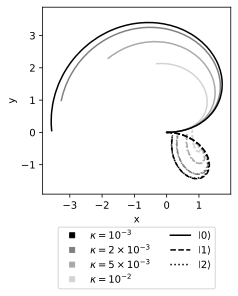

In [5]:

first_dominant_freq =find_dominant_frequency(results[1].expect[0],tlist)
print(first_dominant_freq)


plt.figure(figsize=(3+3/8,3+3/8))

black_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='black', linestyle='-')
gray_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='gray', linestyle='-')
dark_gray_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='darkgray', linestyle='-')
light_gray_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='lightgray', linestyle='-')


solid_line, = plt.plot([], [], color='black', linestyle='-')
dashed_line, = plt.plot([], [], color='black', linestyle='--')
dot_line, = plt.plot([], [], color='black', linestyle=':')

legend_lines = (black_line, gray_line, dark_gray_line, light_gray_line,
                solid_line,dashed_line,dot_line)
legend_labels = (r'$\kappa=10^{-3}$',r'$\kappa=2\times10^{-3}$',r'$\kappa=5\times10^{-3}$', r'$\kappa=10^{-2}$', 
                 rf'$\left|{0}\right>$',rf'$\left|{1}\right>$',rf'$\left|{2}\right>$')



# different settings have different color
for list_of_results,kappa,color in reversed(list(zip([detection_results_1em3,detection_results_2em3,detection_results_5em3,detection_results_1em2],
                                                     ["10^{-3}",r"2\times10^{-3}",r"5\times10^{-3}",r"10^{-2}"],
                                                     ['black','gray','darkgray','lightgray']))):
    # different initial states has different line shape

    for i, linestype in zip([0,1,2],['-',':','--']):
        alpha = list_of_results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
        line, = plt.plot(-alpha.imag,alpha.real,label=rf'$\left|{i}\right>,\kappa={kappa}$',color=color,linestyle=linestype)




plt.xlim(-4,4)
plt.ylim(-4,4)

plt.legend(legend_lines, legend_labels,
            loc='upper center', 
            bbox_to_anchor=(0.5, -0.15), 
            ncol=2)
# plt.axis('equal')
# plt.savefig("fig05_alpha.pdf", format='pdf', bbox_inches='tight')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [42]:
dressed_state=detection_results_1em3[0].states[-1]
product_to_dressed=system.product_to_dressed

qubit_level = 25
osc_level = 40

dressed_dm_data = dressed_state.full()
rho_product = np.zeros((qubit_level * osc_level, qubit_level * osc_level), dtype=complex)
for (ql, ol), dressed_level in product_to_dressed.items():
    index1 = ql * osc_level + ol
    # Loop again to populate the density matrix
    for (ql2, ol2), dressed_level2 in product_to_dressed.items():
        index2 = ql2 * osc_level + ol2
        # TODO  the order of product_state and product_state2 doesn't make sense to me, but it produces the right result. :(
        element = dressed_dm_data[dressed_level, dressed_level2]
        rho_product[index1, index2] += element
rho_product = qutip.Qobj(rho_product, dims=[[qubit_level, osc_level], [qubit_level, osc_level]])
rho_coherent = rho_product.ptrace(1)
# rho_coherent = 0.5 * (rho_coherent + rho_coherent.dag())


A = rho_coherent
A_dagger = A.dag()


3.132673936146303e-11

nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() (2.061871293354733e-11+0j)
nonhermicity: Frobenius norm of the difference between rho and rho dag 3.132673936146303e-11
trace: 0.999999999998921
nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() (5.068286175640434e-07+0j)
nonhermicity: Frobenius norm of the difference between rho and rho dag 1.3309129495185067e-06
trace: 0.9999999999999978


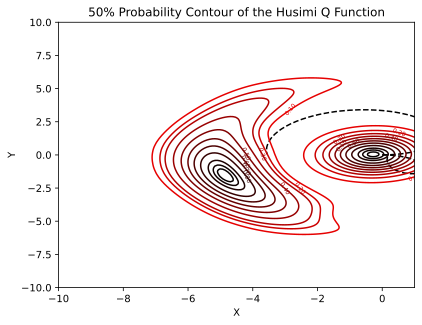

In [54]:

qubit_level = 25
osc_level = 40
system = fluxonium_oscillator_system(
    EJ = 3,
    EC = 0.6,
    EL = 0.13,
    Er = 7.2622522,
    g_strength = 0.3,
    qubit_level = qubit_level,
    osc_level = osc_level,
    kappa = 1e-3,
    products_to_keep=[[ql, ol] for ql in [0] for ol in range(40) ]
    )

def plot_husimi_probability_contours(dressed_state,product_to_dressed,qubit_level,osc_level):
    dressed_dm_data = dressed_state.full()
    rho_product = np.zeros((qubit_level * osc_level, qubit_level * osc_level), dtype=complex)
    for (ql, ol), dressed_level in product_to_dressed.items():
        index1 = ql * osc_level + ol
        # Loop again to populate the density matrix
        for (ql2, ol2), dressed_level2 in product_to_dressed.items():
            index2 = ql2 * osc_level + ol2
            # TODO  the order of product_state and product_state2 doesn't make sense to me, but it produces the right result. :(
            element = dressed_dm_data[dressed_level, dressed_level2]
            rho_product[index1, index2] += element
    rho_product = qutip.Qobj(rho_product, dims=[[qubit_level, osc_level], [qubit_level, osc_level]])
    rho_coherent = rho_product.ptrace(1)

    print(f"nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() {abs(rho_coherent - rho_coherent.dag()).data.max()}")
    print(f"nonhermicity: Frobenius norm of the difference between rho and rho dag {np.linalg.norm((rho_coherent - rho_coherent.dag()).full(), 'fro')}")
    rho_coherent = 0.5 * (rho_coherent + rho_coherent.dag())

    print(f"trace: {rho_coherent.tr()}")
    rho_coherent = rho_coherent / rho_coherent.tr()


    xvec = np.linspace(-20,20,500)

    Q_coherent = qutip.qfunc(rho_coherent, xvec, xvec)

    q_values = Q_coherent
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]
    X, Y = np.meshgrid(xvec, xvec)
    for prob in [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.02]:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        contour = plt.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
        fmt = {level_value:f'{1 - prob:.2f}'}
        plt.clabel(contour, inline=False, fontsize=6, fmt=fmt)

alpha = detection_results_1em3[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
line, = plt.plot(-alpha.imag,alpha.real,label=rf'$\left|{0}\right>,\kappa={kappa}$',color=color,linestyle=linestype)

alpha = detection_results_1em3[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
line, = plt.plot(-alpha.imag,alpha.real,label=rf'$\left|{1}\right>,\kappa={kappa}$',color=color,linestyle=linestype)

plot_husimi_probability_contours(dressed_state=detection_results_1em3[0].states[-1],
                                 product_to_dressed=system.product_to_dressed,
                                 qubit_level = qubit_level,
                                 osc_level = osc_level)
plot_husimi_probability_contours(dressed_state=detection_results_1em3[1].states[-1],
                                 product_to_dressed=system.product_to_dressed,
                                 qubit_level = qubit_level,
                                 osc_level = osc_level)

plt.title("50% Probability Contour of the Husimi Q Function")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-10,1)
plt.ylim(-10,10)
plt.show()

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_34028/3280058756.py: 20

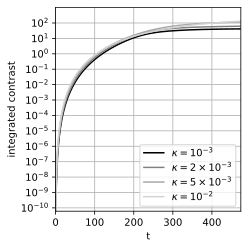

In [71]:
plt.figure(figsize=(3+3/8,3+3/8))

for list_of_results,kappa,kappa_val,color in zip([detection_results_1em3,detection_results_2em3,detection_results_5em3,detection_results_1em2],
                                                     ["10^{-3}",r"2\times10^{-3}",r"5\times10^{-3}",r"10^{-2}"],
                                                [1e-3,2e-3,5e-3,1e-2],
                                                ['black','gray','darkgray','lightgray']):
    alpha0 = list_of_results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alpha1 = list_of_results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    squared_diff = np.square(abs(alpha0-alpha1))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                         )
        
    plt.plot(tlist,integrals,label=rf'$\kappa={kappa}$',color=color)

plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()



In [60]:
state_0_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed - state_1_dressed).unit()
initial_states  = [state_0_dressed,state_1_dressed,state_plus_dressed,state_minus_dressed ]

ntraj = 400

tomo_results = [None] * 4
    
# for i in range(4):
#     print(f'doing qubit initial state {i}')
#     tomo_results[i] = qutip.mcsolve(psi0=truncate_function(initial_states[i]), 
#                                H=H_with_drive,
#                                progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
#                                tlist=tlist, 
#                                c_ops = [decay_term],
#                                ntraj = ntraj,
#                                options=qutip.Options(store_states=True)
#                                )

# import pickle
# with open('mcsolve_tomo_results_kappa1e-3_15levels.pkl', 'wb') as file:
#     pickle.dump(tomo_results, file)

# with open('mcsolve_tomo_results_kappa1e-3levels.pkl', 'rb') as file:
#     tomo_results = pickle.load(file)

In [8]:


state_0_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed - state_1_dressed).unit()
initial_states  = [state_0_dressed,state_1_dressed,state_plus_dressed,state_minus_dressed ]

ntraj = 400

tomo_results = [None] * 4
    
for i in range(4):
    print(f'doing qubit initial state {i}')
    tomo_results[i] = qutip.mcsolve(psi0=truncate_function(initial_states[i]), 
                               H=H_with_drive,
                               progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
                               tlist=tlist, 
                               c_ops = [decay_term],
                               ntraj = ntraj,
                               options=qutip.Options(store_states=True)
                               )

import pickle
with open('mcsolve_tomo_results_kappa1e-3.pkl', 'wb') as file:
    pickle.dump(tomo_results, file)

# with open('mcsolve_tomo_results_kappa1e-3.pkl', 'rb') as file:
#     tomo_results = pickle.load(file)

doing qubit initial state 0
 Total run time: 1738.13s] Elapsed 1738.12s / Remaining 00:00:00:00
doing qubit initial state 1
 Total run time: 1696.04s] Elapsed 1696.03s / Remaining 00:00:00:00
doing qubit initial state 2
 Total run time: 1701.16s] Elapsed 1701.15s / Remaining 00:00:00:00
doing qubit initial state 3
 Total run time: 1738.85s] Elapsed 1738.84s / Remaining 00:00:00:00


# result.states is a 2-d array of shape (n_traj, len(tlist)), each element is a ket,

## we first do averaging over the ntraj kets

In [4]:
with open('mcsolve_tomo_results_kappa1e-3.pkl', 'rb') as file:
    tomo_results = pickle.load(file)
ntraj = 400
dm_tomo_results_list = []
for result in tomo_results:
    new_result = qutip.solver.Result()
    new_result.times = result.times

    states_array = np.array([[state.full() for state in traj] for traj in result.states])
    summed_dm_array = np.einsum('ntrc,ntij->tri', states_array, states_array.conj()) # n is traj index, t is time index, r is row index, c is column index, i and j are the row and column index of the conjugated ket
    averaged_dm_array = summed_dm_array/ntraj
    new_result.states = [qutip.Qobj(dm) for dm in averaged_dm_array]

    dm_tomo_results_list.append(new_result)


In [68]:
from matplotlib.colors import LogNorm

def plot_heatmap(result, time_index, product_to_dressed, qubit_levels, oscillator_levels):
    if hasattr(result, 'states'):
        dm = result.states[time_index]
    elif hasattr(result, 'y'):
        dm = result.y[time_index]

    # dm = pad_back_function(dm)
    grid = np.zeros(( qubit_levels,oscillator_levels))

    for qubit_level in range(qubit_levels):
        for oscillator_level in range(oscillator_levels):
            product_state = (qubit_level, oscillator_level)
            dressed_state = product_to_dressed[product_state]
            if dressed_state < dm.dims[0][0]:
                # Create a basis state corresponding to the dressed state
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                # Calculate the expectation value
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
            else:
                expectation_value = 0
            grid[ qubit_level,oscillator_level] = expectation_value
    grid[grid < 1e-5] = 1e-5
    plt.imshow(grid, cmap='viridis', origin='lower', norm=LogNorm(vmax=1,vmin=1e-5))
    plt.colorbar(label='Expectation Value')
    plt.xlabel('Oscillator Level')
    plt.ylabel('Qubit Level')
    plt.title(f'Expectation Values at t = {result.times[time_index]}')
    plt.show()

def interactive_heatmap(result, product_to_dressed, qubit_levels, oscillator_levels):
    if hasattr(result, 'times'):
        times = result.times
    elif hasattr(result, 't'):
        times = result.t
    time_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(times) - 1,
        step=1,
        description='Time Index:',
        continuous_update=False
    )
    
    widgets.interact(lambda time_index: plot_heatmap(result, time_index, product_to_dressed, qubit_levels, oscillator_levels),
                     time_index=time_slider)

# because we need to do partial trace to get qubit dm, we have to convert the truncated dressed dm into a product dm

In [10]:
import shutil
dir_name = 'temp_tomo'
if os.path.exists(dir_name):
    shutil.rmtree(dir_name)
os.mkdir(dir_name)
tasks = [(dm_tomo_results_list, 
          f'{dir_name}/res_{i}_state_{j}.pkl',
          i, j,  product_to_dressed, qubit_level, osc_level, 1, 2,products_to_keep) 
         for i in range(len(dm_tomo_results_list)) 
         for j in range(len(dm_tomo_results_list[i].states))]

from multiprocessing import Pool

with Pool(processes=6) as pool:
    pool.map(compute_and_store_2_level_dm, tasks)

In [11]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [zero,
              one,
              (zero +  one).unit(),
              (zero - one).unit() ]


num_initial_states = len(dm_tomo_results_list)
num_time_steps = len(dm_tomo_results_list[0].times)
two_level_states = []
for i in range(num_initial_states) :
    two_level_states.append([])
    for j in range(num_time_steps):
        with open(f'{dir_name}/res_{i}_state_{j}.pkl', 'rb') as f:
            state = pickle.load(f)
        two_level_states[-1].append(state)


Text(0.5, 0, 'ns')

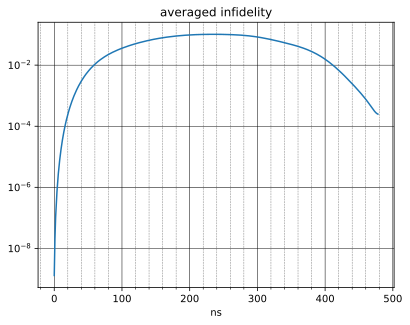

In [12]:
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*dm_ideal))

    return 1-sum(fid)/len(fid)
    


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [states[idx] for states in two_level_states]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)


plt.plot(dm_tomo_results_list[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

In [15]:
import pickle
with open('mcsolve_infidelity_kappa1e-3.pkl', 'wb') as file:
    pickle.dump(infidelity, file)